In [ ]:
######## SETUP AND INITIALIZATION ########

import os
import stanza
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from conllu import parse
from scipy.stats import ks_2samp
import random

# Language mapping
LANGS = {
    'ar': 'arabic', 'de': 'german', 'en': 'english', 'fi': 'finnish', 
    'fr': 'french', 'hi': 'hindi', 'ja': 'japanese', 'ru': 'russian', 
    'tr': 'turkish', 'zh': 'chinese-simplified'
}

SUD_DIR = "data/sud-banks"
LLM_RAW_DIR = "data/llm-data/llm-raw"
LLM_PARSED_DIR = "data/llm-data/llm-parsed"

# Initialize pipelines safely
pipelines = {}
for code in LANGS.keys():
    print(f"--- Initializing {LANGS[code]} ({code}) ---")
    try:
        pipelines[code] = stanza.Pipeline(lang=code, processors='tokenize,mwt,pos,lemma,depparse')
    except:
        print(f"  > MWT not supported for {code}. Initializing without it...")
        pipelines[code] = stanza.Pipeline(lang=code, processors='tokenize,pos,lemma,depparse')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 02:30:57 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


--- Initializing arabic (ar) ---


2026-04-25 02:30:57 INFO: Downloaded file to /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/resources.json
2026-04-25 02:30:58 INFO: Loading these models for language: ar (Arabic):
| Processor | Package       |
-----------------------------
| tokenize  | padt          |
| mwt       | padt          |
| pos       | padt_charlm   |
| lemma     | padt_nocharlm |
| depparse  | padt_charlm   |

2026-04-25 02:30:58 INFO: Using device: cpu
2026-04-25 02:30:58 INFO: Loading: tokenize
2026-04-25 02:30:58 INFO: Loading: mwt
2026-04-25 02:30:58 INFO: Loading: pos
2026-04-25 02:30:59 INFO: Loading: lemma
2026-04-25 02:30:59 INFO: Loading: depparse
2026-04-25 02:30:59 INFO: Done loading processors!
2026-04-25 02:30:59 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


--- Initializing german (de) ---


2026-04-25 02:30:59 INFO: Downloaded file to /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/resources.json
2026-04-25 02:31:00 INFO: Loading these models for language: de (German):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2026-04-25 02:31:00 INFO: Using device: cpu
2026-04-25 02:31:00 INFO: Loading: tokenize
2026-04-25 02:31:00 INFO: Loading: mwt
2026-04-25 02:31:00 INFO: Loading: pos
2026-04-25 02:31:01 INFO: Loading: lemma
2026-04-25 02:31:04 INFO: Loading: depparse
2026-04-25 02:31:04 INFO: Done loading processors!
2026-04-25 02:31:04 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


...

2026-04-25 02:31:20 INFO: Downloaded file to /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/resources.json
2026-04-25 02:31:20 INFO: Loading these models for language: tr (Turkish):
| Processor | Package       |
-----------------------------
| tokenize  | imst          |
| mwt       | imst          |
| pos       | imst_charlm   |
| lemma     | imst_nocharlm |
| depparse  | imst_charlm   |

2026-04-25 02:31:20 INFO: Using device: cpu
2026-04-25 02:31:20 INFO: Loading: tokenize
2026-04-25 02:31:20 INFO: Loading: mwt
2026-04-25 02:31:20 INFO: Loading: pos
2026-04-25 02:31:21 INFO: Loading: lemma
2026-04-25 02:31:21 INFO: Loading: depparse
2026-04-25 02:31:21 INFO: Done loading processors!
2026-04-25 02:31:21 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


--- Initializing chinese-simplified (zh) ---


2026-04-25 02:31:21 INFO: Downloaded file to /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/resources.json
2026-04-25 02:31:21 INFO: "zh" is an alias for "zh-hans"
2026-04-25 02:31:23 INFO: Loading these models for language: zh-hans (Simplified_Chinese):
| Processor | Package          |
--------------------------------
| tokenize  | gsdsimp          |
| mwt       | default          |
| pos       | gsdsimp_charlm   |
| lemma     | gsdsimp_nocharlm |
| depparse  | gsdsimp_charlm   |

2026-04-25 02:31:23 INFO: Using device: cpu
2026-04-25 02:31:23 INFO: Loading: tokenize
2026-04-25 02:31:23 INFO: Loading: mwt
2026-04-25 02:31:23 ERROR: Cannot load model from /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/zh-hans/mwt/default.pt
2026-04-25 02:31:23 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


  > MWT not supported for zh. Initializing without it...


2026-04-25 02:31:23 INFO: Downloaded file to /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/resources.json
2026-04-25 02:31:23 INFO: "zh" is an alias for "zh-hans"
2026-04-25 02:31:24 INFO: Loading these models for language: zh-hans (Simplified_Chinese):
| Processor | Package          |
--------------------------------
| tokenize  | gsdsimp          |
| pos       | gsdsimp_charlm   |
| lemma     | gsdsimp_nocharlm |
| depparse  | gsdsimp_charlm   |

2026-04-25 02:31:24 INFO: Using device: cpu
2026-04-25 02:31:24 INFO: Loading: tokenize
2026-04-25 02:31:24 INFO: Loading: pos
2026-04-25 02:31:25 INFO: Loading: lemma
2026-04-25 02:31:25 INFO: Loading: depparse
2026-04-25 02:31:25 INFO: Done loading processors!


In [ ]:
######## CONSTRUCTION OF GRAPHS USING NETWORKX ########

import networkx as nx
def get_metrics_safe(sentence_nodes):
    G = nx.DiGraph()
    edges = []
    dep_length = 0
    crossings = 0
    
    nodes_indices = [int(token['id']) for token in sentence_nodes if isinstance(token['id'], int)]
    n_nodes = len(nodes_indices)
    
    if n_nodes > 80 or n_nodes < 2:
        return {'arity': 0, 'depth': 0, 'density': 0, 'dep_length': 0, 'crossings': 0, 'n_tokens': n_nodes}

    for token in sentence_nodes:
        # SAFETY CHECK: Skip if ID is not an int OR if head/id is missing (None)
        if not isinstance(token['id'], int) or token['id'] is None or token['head'] is None:
            continue 
            
        child, head = int(token['id']), int(token['head'])
        
        if head != 0: 
            G.add_edge(head, child)
            edges.append((head, child))
            dep_length += abs(head - child)
    
    # Tree Arity
    arity = max([d for n, d in G.out_degree()] + [0])
    
    # Tree Depth
    try:
        roots = [n for n, d in G.in_degree() if d == 0]
        depth = max([max(nx.shortest_path_length(G, source=r).values()) for r in roots] + [0])
    except:
        depth = 0
    
    # Density and MDL
    density = len(edges) / (n_nodes * (n_nodes - 1)) if n_nodes > 1 else 0
    norm_dep_length = dep_length / n_nodes
    
    # Crossings
    for i in range(len(edges)):
        for j in range(i + 1, len(edges)):
            e1, e2 = sorted(edges[i]), sorted(edges[j])
            if e1[0] < e2[0] < e1[1] < e2[1] or e2[0] < e1[0] < e2[1] < e1[1]:
                crossings += 1

    return {
        'arity': arity, 'depth': depth, 'density': density, 
        'dep_length': norm_dep_length, 'crossings': crossings, 'n_tokens': n_nodes
    }

In [3]:
# # Quick test: "The cat sat" (Simplified: 2->1, 2->3)
# test_sent = [
#     {'id': 1, 'head': 2}, # The -> cat
#     {'id': 2, 'head': 0}, # cat (root)
#     {'id': 3, 'head': 2}  # sat -> cat
# ]
# print(get_metrics(test_sent))

In [ ]:
####### GENERATING RANDOM BASELINE TREES ########

import random
def generate_random_tree_metrics(n_nodes):
    if n_nodes < 2 or n_nodes > 80:
        return {'arity': 0, 'depth': 0, 'density': 0, 'dep_length': 0, 'crossings': 0, 'n_tokens': n_nodes}
    
    nodes = list(range(1, n_nodes + 1))
    random.shuffle(nodes)
    tree_nodes, remaining_nodes = [nodes[0]], nodes[1:]
    simulated_tokens = [{'id': nodes[0], 'head': 0}]
    
    while remaining_nodes:
        parent = random.choice(tree_nodes)
        child = remaining_nodes.pop()
        simulated_tokens.append({'id': child, 'head': parent})
        tree_nodes.append(child)
        
    return get_metrics_safe(simulated_tokens)

In [ ]:
######## takes long time to run and only needs to be run once, so keeping it commented for now uncomment to execute the full pipeline #######

# import gc
# import stanza
# import os
# import pandas as pd
# from conllu import parse_incr

# # PARAMETERS
# TARGET_MODELS = ['chatgpt'] #change model name here
# SUD_SAMPLE_LIMIT = 400

# results = []

# for lang_code in LANGS.keys():
#     print(f"\n>>> PROCESSING: {lang_code.upper()} <<<")
    
#     # 1. load pipelines one at a time
#     try:
#         nlp = stanza.Pipeline(lang=lang_code, processors='tokenize,mwt,pos,lemma,depparse', verbose=False, use_gpu=False)
#     except:
#         nlp = stanza.Pipeline(lang=lang_code, processors='tokenize,pos,lemma,depparse', verbose=False, use_gpu=False)

#     # 2. PROCESS HUMAN DATA
#     sud_files = [f for f in os.listdir(SUD_DIR) if f.startswith(f"{lang_code}_")]
#     if sud_files:
#         count = 0
#         with open(os.path.join(SUD_DIR, sud_files[0]), 'r', encoding='utf-8') as f:
#             for sent in parse_incr(f):
#                 if count >= SUD_SAMPLE_LIMIT: break
#                 m = get_metrics_safe(sent)
#                 if m['arity'] > 0: # Ensures it's a valid parsed tree
#                     m.update({'lang': lang_code, 'source': 'Human', 'model': 'N/A'})
#                     results.append(m)
#                     r = generate_random_tree_metrics(m['n_tokens'])
#                     r.update({'lang': lang_code, 'source': 'Random', 'model': 'N/A'})
#                     results.append(r)
#                     count += 1
#         print(f"  [Human] Done: {count} samples.")

#     # 3. PROCESS LLM DATA in chunks
#     for model in TARGET_MODELS:
#         raw_path = os.path.join(LLM_RAW_DIR, model, f"{lang_code}.txt")
#         if os.path.exists(raw_path):
#             print(f"  [LLM] Parsing {model.upper()}...")
#             with open(raw_path, 'r', encoding='utf-8') as f:
#                 lines = [line.strip() for line in f if line.strip()]
            
#             conllu_buffer = []
#             for line in lines:
#                 doc = nlp(line) # Parse sentence by sentence to keep RAM flat
#                 for sent in doc.sentences:
#                     sent_dicts = [{'id': word.id, 'head': word.head} for word in sent.words]
#                     m = get_metrics_safe(sent_dicts)
#                     if m['arity'] > 0:
#                         m.update({'lang': lang_code, 'source': 'LLM', 'model': model})
#                         results.append(m)
                        
#                         conllu_buffer.append(f"# text = {sent.text}")
#                         for word in sent.words:
#                             conllu_buffer.append(f"{word.id}\t{word.text}\t{word.lemma}\t{word.upos}\t_\t_\t{word.head}\t{word.deprel}\t_\t_")
#                         conllu_buffer.append("")

#             # Save parsed conluu
#             out_path = os.path.join(LLM_PARSED_DIR, model, f"{lang_code}.conllu")
#             os.makedirs(os.path.dirname(out_path), exist_ok=True)
#             with open(out_path, 'w', encoding='utf-8') as out_f:
#                 out_f.write("\n".join(conllu_buffer))

#     # 4. cleanup to avoid memory strain
#     del nlp
#     gc.collect()
#     print(f"--- {lang_code.upper()} CLEAR ---")

# # 5. final result exporting
# df = pd.DataFrame(results)
# df.to_csv("structural_analysis_results.csv", index=False)


>>> PROCESSING: AR <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- AR CLEAR ---

>>> PROCESSING: DE <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- DE CLEAR ---

>>> PROCESSING: EN <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- EN CLEAR ---

>>> PROCESSING: FI <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- FI CLEAR ---

>>> PROCESSING: FR <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- FR CLEAR ---

>>> PROCESSING: HI <<<


2026-04-25 11:36:09 ERROR: Cannot load model from /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/hi/mwt/default.pt


  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- HI CLEAR ---

>>> PROCESSING: JA <<<


2026-04-25 11:36:47 ERROR: Cannot load model from /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/ja/mwt/default.pt


  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- JA CLEAR ---

>>> PROCESSING: RU <<<


2026-04-25 11:37:16 ERROR: Cannot load model from /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/ru/mwt/default.pt


  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- RU CLEAR ---

>>> PROCESSING: TR <<<
  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- TR CLEAR ---

>>> PROCESSING: ZH <<<


2026-04-25 11:38:43 ERROR: Cannot load model from /Users/saatviksingh/Library/Caches/stanza/1.11.0/resources/zh-hans/mwt/default.pt


  [Human] Done: 400 samples.
  [LLM] Parsing CHATGPT...
--- ZH CLEAR ---


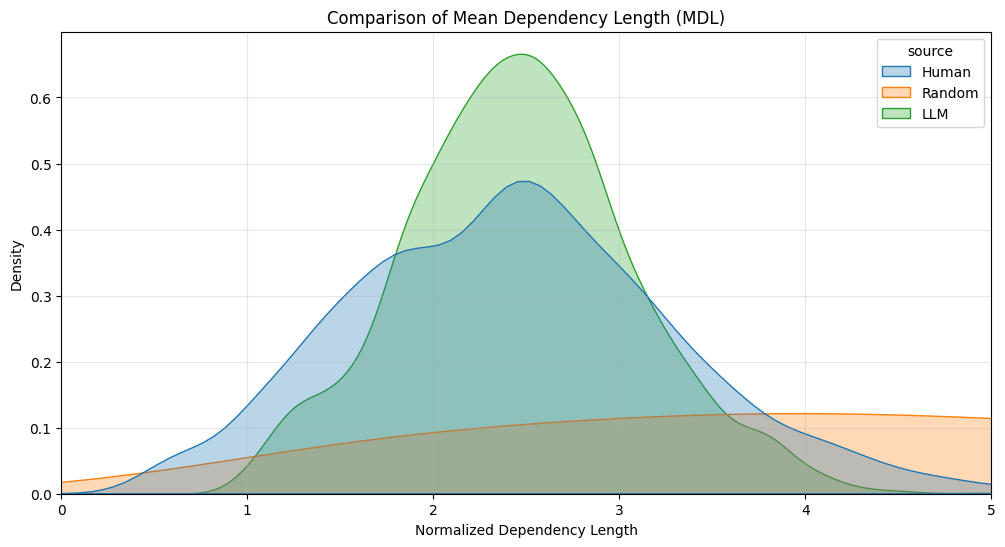

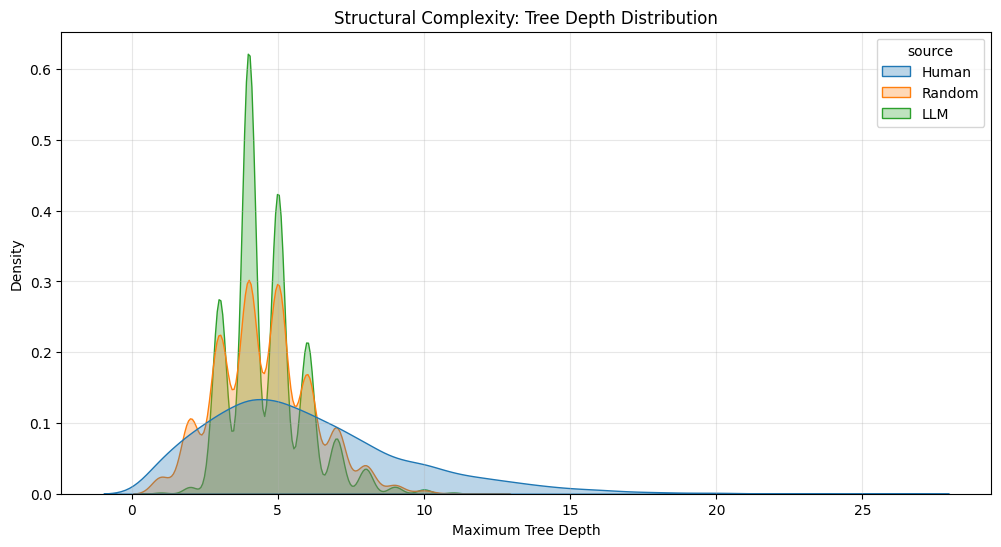

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the results
df = pd.read_csv("chatgpt-structural_analysis_results.csv") #change file name to get results from respective model data

# Filter out the 'guardrail' rows where arity was 0 (the skipped long sentences)
df_clean = df[df['arity'] > 0].copy()

# 1. viz of dependency lenght (DDM test)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_clean, x='dep_length', hue='source', common_norm=False, fill=True, alpha=0.3)
plt.title("Comparison of Mean Dependency Length (MDL)")
plt.xlabel("Normalized Dependency Length")
plt.ylabel("Density")
plt.xlim(0, 5) # focus on most common range
plt.grid(alpha=0.3)
plt.show()

# 2. viz of tree depth
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_clean, x='depth', hue='source', common_norm=False, fill=True, alpha=0.3)
plt.title("Structural Complexity: Tree Depth Distribution")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

In [41]:
### significance testing (KS test) across all languages and both metrics, comparing human vs llm ###########

from scipy.stats import ks_2samp

final_report = []

for lang in df_clean['lang'].unique():
    for metric in ['dep_length', 'depth']:
        human = df_clean[(df_clean['lang'] == lang) & (df_clean['source'] == 'Human')][metric]
        llm = df_clean[(df_clean['lang'] == lang) & (df_clean['source'] == 'LLM')][metric]
        
        if not llm.empty and not human.empty:
            stat, p = ks_2samp(human, llm)
            final_report.append({
                'Language': lang,
                'Metric': metric,
                'D-Statistic': round(stat, 4),
                'P-Value': f"{p:.2e}",
                'Significant?': p < 0.05
            })

report_df = pd.DataFrame(final_report)
report_df.to_csv("final_significance_report.csv", index=False)
display(report_df)

,Language,Metric,D-Statistic,P-Value,Significant?
0,ar,dep_length,0.3205,3.29e-20,True
1,ar,depth,0.4843,1.24e-46,True
2,de,dep_length,0.4942,1.49e-49,True
3,de,depth,0.2050,1.30e-08,True
4,en,dep_length,0.2975,7.74e-18,True
5,en,depth,0.6600,3.82e-92,True
6,fi,dep_length,0.2028,1.82e-08,True
7,fi,depth,0.2895,7.02e-17,True
8,fr,dep_length,0.3057,8.29e-19,True
9,fr,depth,0.4934,1.54e-49,True


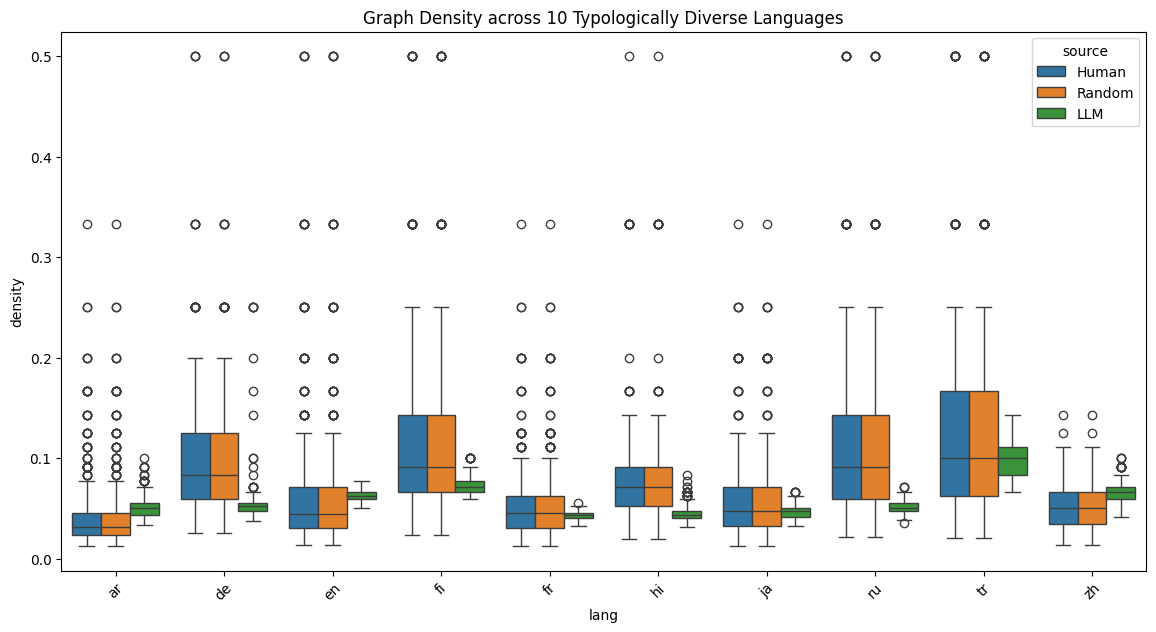

In [17]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean, x='lang', y='density', hue='source')
plt.title("Graph Density across 10 Typologically Diverse Languages")
plt.xticks(rotation=45)
plt.show()

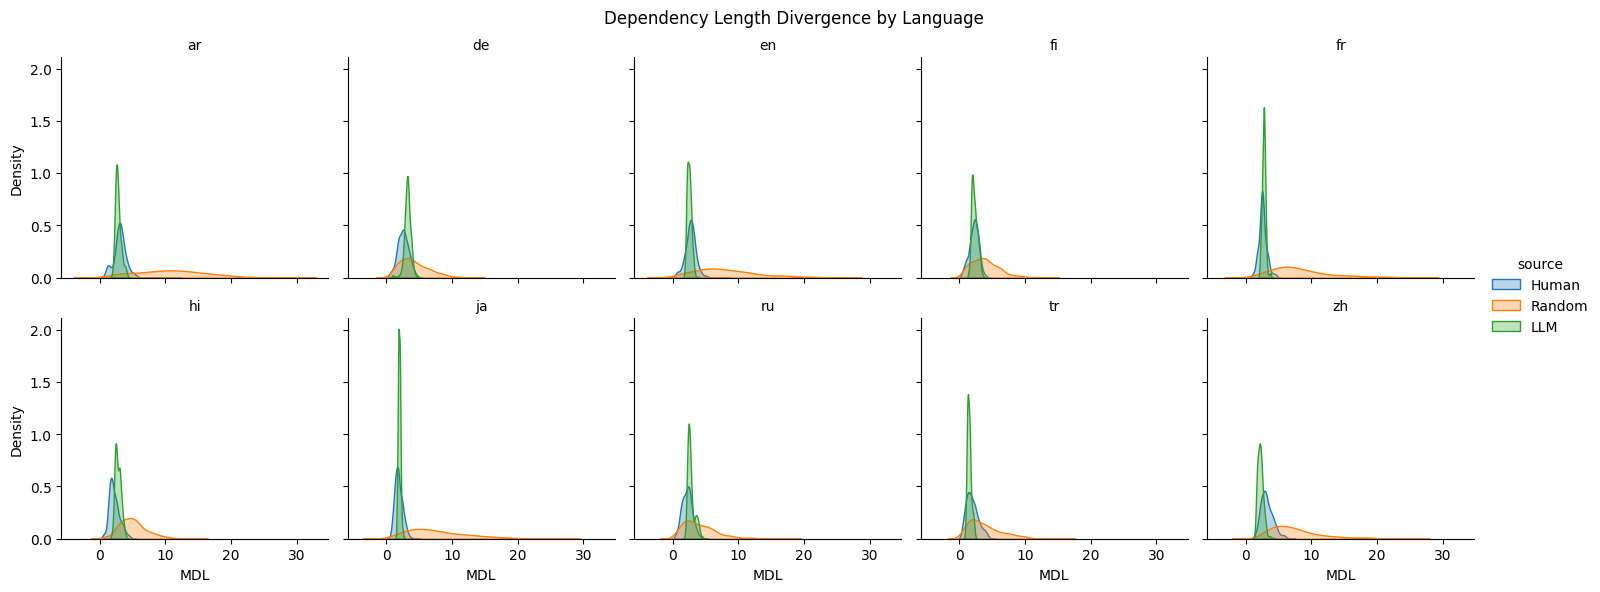

In [ ]:
# Create a grid of plots one for each language
g = sns.FacetGrid(df_clean, col="lang", hue="source", col_wrap=5, height=3)
g.map(sns.kdeplot, "dep_length", fill=True, alpha=0.3)
g.add_legend()
g.set_axis_labels("MDL", "Density")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Dependency Length Divergence by Language')
plt.show()

In [ ]:
# counts per language and source
print("--- Data Integrity Check ---")
integrity_check = df_clean.groupby(['lang', 'source']).size().unstack(fill_value=0)
display(integrity_check)

# Check if any language is missing llm data
missing = integrity_check[integrity_check['LLM'] == 0].index.tolist()
if missing:
    print(f"WARNING: Missing LLM data for: {missing}")
else:
    print("SUCCESS: All 10 languages have both Human and LLM samples.")

--- Data Integrity Check ---


source,Human,LLM,Random
lang,,,
ar,400,473,400
de,400,493,400
en,400,500,400
fi,400,497,400
fr,400,497,400
hi,400,496,400
ja,400,497,400
ru,400,497,400
tr,400,500,400


SUCCESS: All 10 languages have both Human and LLM samples.


In [ ]:
# check how many sentences were skipped due to the length guardrail (arity=0)
skipped_count = len(df[df['arity'] == 0])
total_count = len(df)
print(f"Skipped sentences (too long): {skipped_count} ({skipped_count/total_count:.2%})")


Skipped sentences (too long): 0 (0.00%)


In [ ]:
# comparing the mean crossings
print("\n--- Projectivity Check (Mean Crossings) ---")
print(df_clean.groupby('source')['crossings'].mean())


--- Projectivity Check (Mean Crossings) ---
source
Human      0.42625
LLM        0.17452
Random    72.24350
Name: crossings, dtype: float64


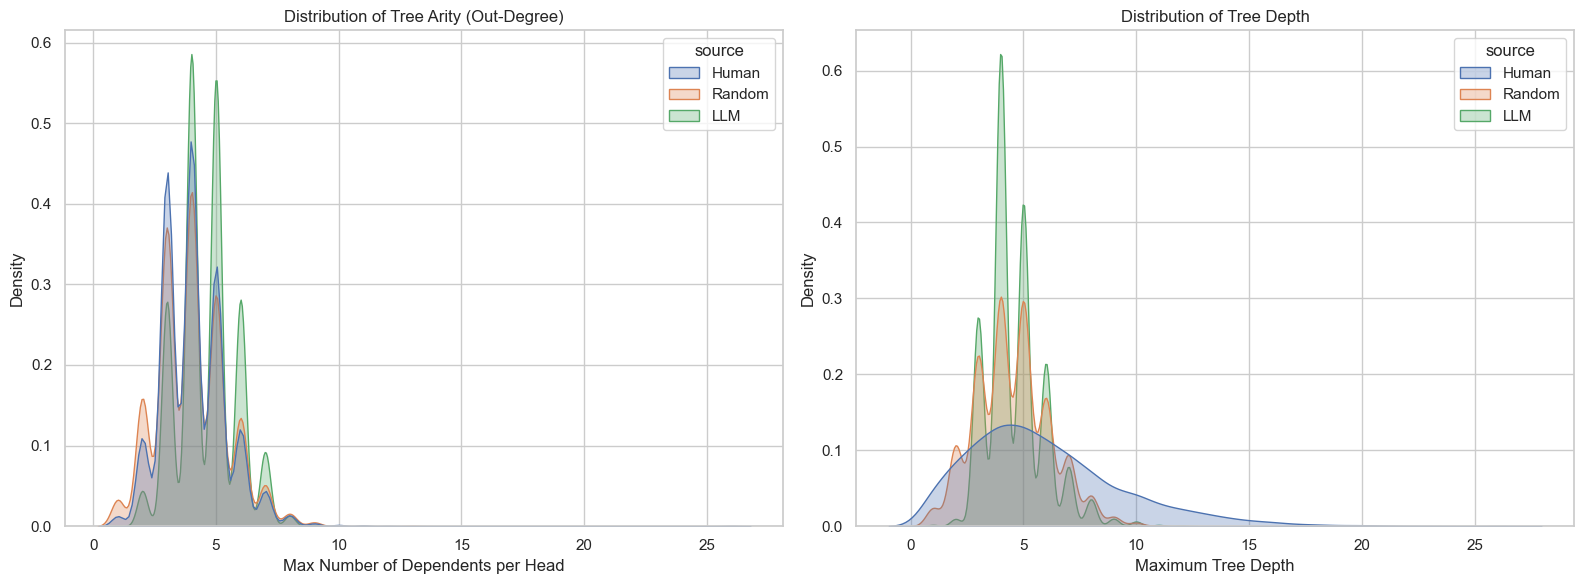

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. arity
sns.kdeplot(data=df_clean, x='arity', hue='source', ax=axes[0], 
            common_norm=False, fill=True, alpha=0.3)
axes[0].set_title("Distribution of Tree Arity (Out-Degree)")
axes[0].set_xlabel("Max Number of Dependents per Head")
axes[0].set_ylabel("Density")

# 2. depth
sns.kdeplot(data=df_clean, x='depth', hue='source', ax=axes[1], 
            common_norm=False, fill=True, alpha=0.3)
axes[1].set_title("Distribution of Tree Depth")
axes[1].set_xlabel("Maximum Tree Depth")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [29]:
df_clean.groupby('source')['dep_length'].mean()

source
Human     2.447503
LLM       2.461708
Random    6.442706
Name: dep_length, dtype: float64

In [30]:
df_clean.groupby('source')['depth'].mean()

source
Human     5.939000
LLM       4.613347
Random    4.524000
Name: depth, dtype: float64

In [46]:
# Convert RGB to 0-1 scale
def rgb(r, g, b):
    return (r/255, g/255, b/255)

custom_palette = {
    "Human": rgb(192, 212, 230),   # Muted Blue
    "Random": rgb(249, 218, 187),  # Muted Orange
    "Gemini": rgb(198, 225, 194),  # Muted Green
    "ChatGPT": rgb(220, 200, 230)  # Muted Purple
}


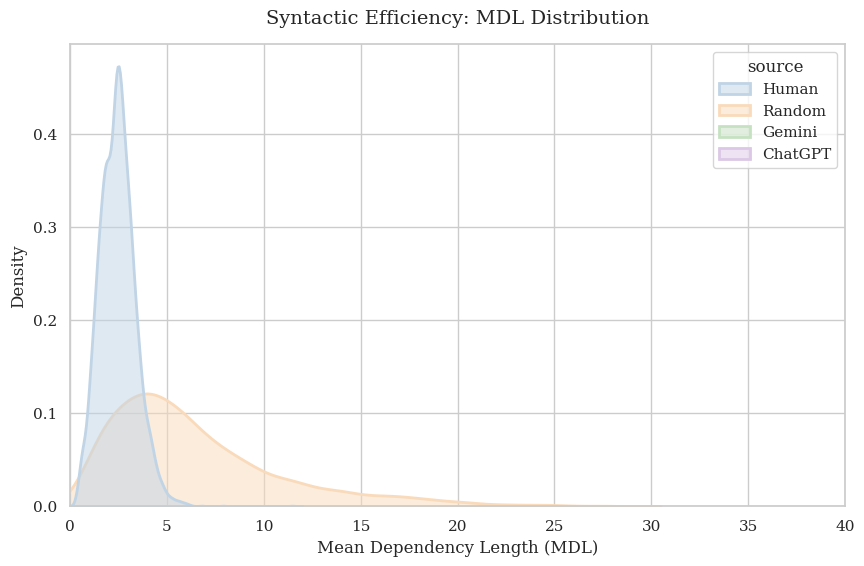

In [47]:
# 2. Generate the MDL KDE Plot
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font="serif")

sns.kdeplot(
    data=df_clean, x='dep_length', hue='source', 
    palette=custom_palette, hue_order=["Human", "Random", "Gemini", "ChatGPT"],
    fill=True, alpha=0.5, common_norm=False, linewidth=2
)

plt.title("Syntactic Efficiency: MDL Distribution", fontsize=14, pad=15)
plt.xlabel("Mean Dependency Length (MDL)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, 40) # Focus on the divergence area

plt.savefig('mdl_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
from scipy.stats import ks_2samp

# 1. Define the metrics we want to test
metrics = {
    'dep_length': 'MDL',
    'depth': 'Tree Depth',
    'arity': 'Arity',
    'crossings': 'Crossings'
}

# 2. Filter data for the two groups
human_data = df_clean[df_clean['source'] == 'Human']
random_data = df_clean[df_clean['source'] == 'Random']

print("--- LaTeX Table Rows ---")
for col, label in metrics.items():
    # Perform KS Test
    d_stat, p_val = ks_2samp(human_data[col], random_data[col])
    
    # Format p-value for LaTeX (using scientific notation if very small)
    p_str = f"{p_val:.2e}" if p_val < 0.001 else f"{p_val:.3f}"
    sig = "True" if p_val < 0.05 else "False"
    
    # Print formatted LaTeX row
    print(f"{label:<15} & {d_stat:.3f} & {p_str} & {sig} \\\\")

--- LaTeX Table Rows ---
MDL             & 0.618 & 0.00e+00 & True \\
Tree Depth      & 0.242 & 2.22e-103 & True \\
Arity           & 0.051 & 4.92e-05 & True \\
Crossings       & 0.799 & 0.00e+00 & True \\


In [44]:
from scipy.stats import ks_2samp

# Filter for the two groups
human_data = df_clean[df_clean['source'] == 'Human']
llm_data = df_clean[df_clean['source'] == 'LLM']

metrics = {'dep_length': 'MDL', 'depth': 'Depth', 'arity': 'Arity', 'crossings': 'Crossings'}

print("--- Data for Section 3.4 Table ---")
for col, label in metrics.items():
    d_stat, p_val = ks_2samp(human_data[col], llm_data[col])
    print(f"{label}: D={d_stat:.3f}, p={p_val:.2e}")

print("\n--- Means for Prose ---")
print(f"Human MDL Mean: {human_data['dep_length'].mean():.2f}")
print(f"LLM MDL Mean: {llm_data['dep_length'].mean():.2f}")

--- Data for Section 3.4 Table ---
MDL: D=0.118, p=1.72e-27
Depth: D=0.283, p=5.07e-157
Arity: D=0.188, p=5.97e-69
Crossings: D=0.124, p=4.29e-30

--- Means for Prose ---
Human MDL Mean: 2.45
LLM MDL Mean: 2.46


In [48]:


# 1. Define your Pastel RGB Palette
def rgb(r, g, b): return (r/255, g/255, b/255)

custom_palette = {
    "Human": rgb(192, 212, 230),   # Muted Blue
    "Random": rgb(249, 218, 187),  # Muted Orange
    "Gemini": rgb(198, 225, 194),  # Muted Green
    "ChatGPT": rgb(220, 200, 230)  # Muted Purple
}
hue_order = ["Human", "Gemini", "ChatGPT", "Random"]

# 2. Load and Separate Models
# We take the Baselines (Human/Random) and Gemini from this file
df_gem = pd.read_csv("gemini-structural_analysis_results.csv")
df_baselines = df_gem[df_gem['source'] != 'LLM'].copy()
df_gemini = df_gem[df_gem['source'] == 'LLM'].copy()
df_gemini['source'] = 'Gemini'

# We take only the ChatGPT data from this file
df_gpt_all = pd.read_csv("chatgpt-structural_analysis_results.csv")
df_chatgpt = df_gpt_all[df_gpt_all['source'] == 'LLM'].copy()
df_chatgpt['source'] = 'ChatGPT'

# 3. Final Concatenation (ALL LANGUAGES)
df_all = pd.concat([df_baselines, df_gemini, df_chatgpt], ignore_index=True)
df_clean = df_all[df_all['arity'] > 0].copy()

print("Full dataset merged.")
print(df_clean.groupby('source').size())

Full dataset merged.
source
ChatGPT    4945
Gemini     5055
Human      4000
Random     4000
dtype: int64


In [49]:
# Aggregate means across all 13,000+ sentences
agg_results = df_clean.groupby('source')[['dep_length', 'depth', 'crossings']].mean()

print("\n--- AGGREGATE RESULTS (ALL LANGUAGES) ---")
print(agg_results)


--- AGGREGATE RESULTS (ALL LANGUAGES) ---
         dep_length     depth  crossings
source                                  
ChatGPT    2.461708  4.613347   0.174520
Gemini     2.865559  5.626706   0.161622
Human      2.447503  5.939000   0.426250
Random     6.449549  4.532500  72.023000


In [50]:
metrics = {'dep_length': 'MDL', 'depth': 'Depth', 'arity': 'Arity', 'crossings': 'Crossings'}
target_models = ['Gemini', 'ChatGPT']

print("\n--- AGGREGATE KS-TESTS (HUMAN VS. MODELS) ---")
for model in target_models:
    print(f"\nComparison: Human vs {model}")
    for col, label in metrics.items():
        h_val = df_clean[df_clean['source'] == 'Human'][col]
        m_val = df_clean[df_clean['source'] == model][col]
        d_stat, p_val = ks_2samp(h_val, m_val)
        print(f"{label:<10} | D-Stat: {d_stat:.3f} | p: {p_val:.2e}")


--- AGGREGATE KS-TESTS (HUMAN VS. MODELS) ---

Comparison: Human vs Gemini
MDL        | D-Stat: 0.295 | p: 2.43e-171
Depth      | D-Stat: 0.192 | p: 2.25e-72
Arity      | D-Stat: 0.357 | p: 3.53e-253
Crossings  | D-Stat: 0.125 | p: 8.73e-31

Comparison: Human vs ChatGPT
MDL        | D-Stat: 0.118 | p: 1.72e-27
Depth      | D-Stat: 0.283 | p: 5.07e-157
Arity      | D-Stat: 0.188 | p: 5.97e-69
Crossings  | D-Stat: 0.124 | p: 4.29e-30


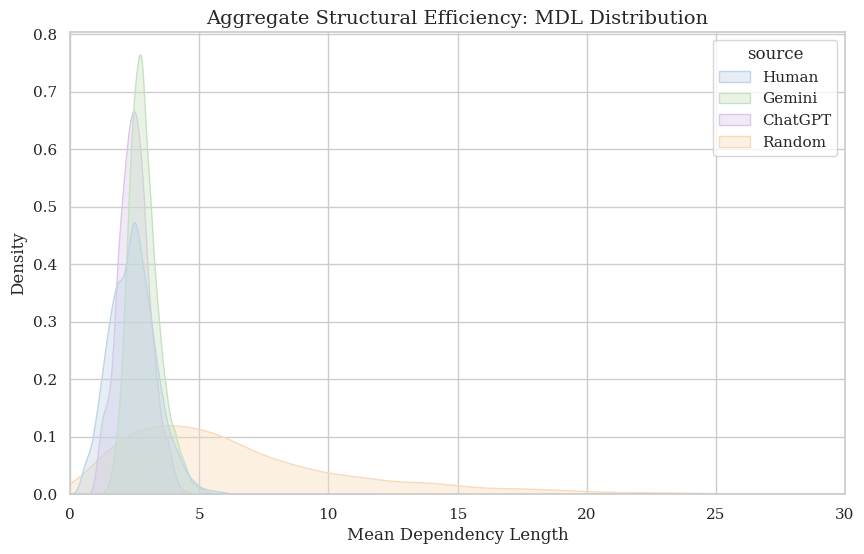

In [51]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='dep_length', hue='source', 
            palette=custom_palette, hue_order=hue_order,
            fill=True, alpha=0.4, common_norm=False)
plt.title("Aggregate Structural Efficiency: MDL Distribution", fontsize=14)
plt.xlabel("Mean Dependency Length")
plt.xlim(0, 30)
plt.savefig('appendix_mdl_all.png', dpi=300)
plt.show()

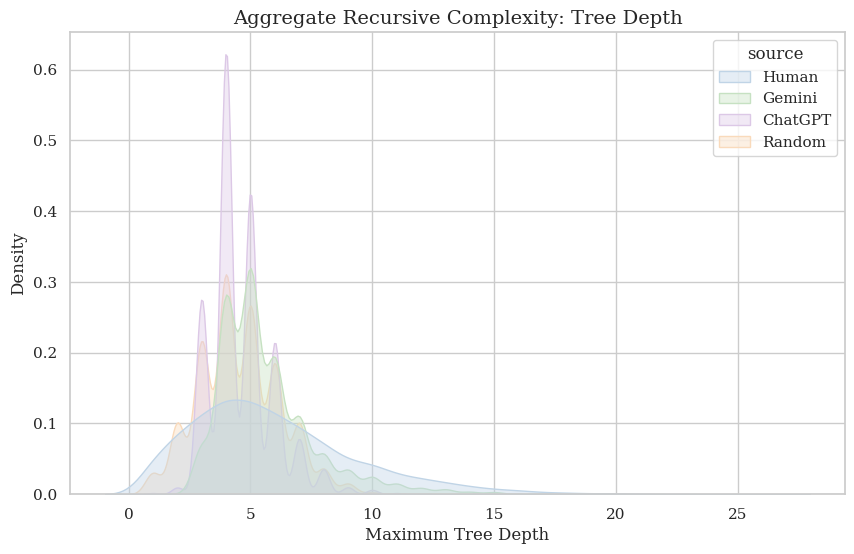

In [52]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_clean, x='depth', hue='source', 
            palette=custom_palette, hue_order=hue_order,
            fill=True, alpha=0.4, common_norm=False)
plt.title("Aggregate Recursive Complexity: Tree Depth", fontsize=14)
plt.xlabel("Maximum Tree Depth")
plt.savefig('appendix_depth_all.png', dpi=300)
plt.show()

/var/folders/dg/x9f6vp3x19s3clvvwpsbypy00000gn/T/ipykernel_70640/2479528553.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=cross_means, x='source', y='crossings',


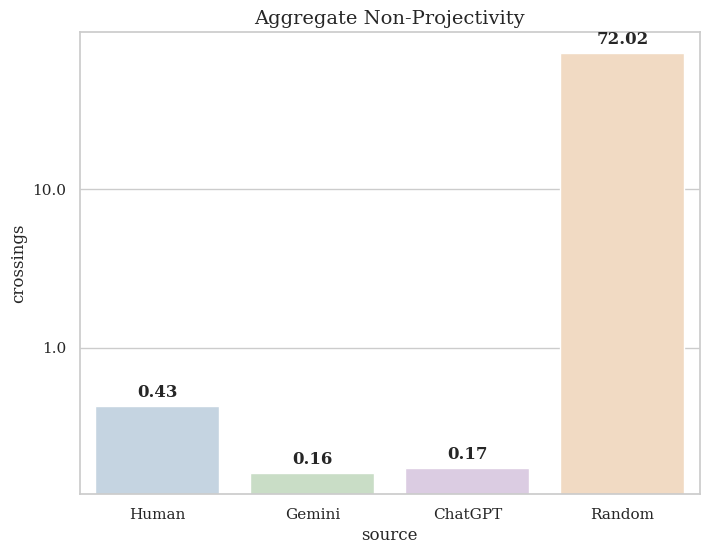

In [53]:
plt.figure(figsize=(8, 6))
cross_means = df_clean.groupby('source')['crossings'].mean().reset_index()
ax = sns.barplot(data=cross_means, x='source', y='crossings', 
                 palette=custom_palette, order=hue_order)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(ScalarFormatter())
plt.title("Aggregate Non-Projectivity", fontsize=14)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold')

plt.savefig('appendix_crossings_all.png', dpi=300)
plt.show()

In [55]:
from scipy.stats import ks_2samp

# Define the cohorts
human = df_clean[df_clean['source'] == 'Human']
gpt = df_clean[df_clean['source'] == 'Gemini']

metrics = [
    ('dep_length', 'MDL'),
    ('depth', 'Tree Depth'),
    ('arity', 'Arity'),
    ('crossings', 'Crossings')
]

print("--- Values for Gemini Column ---")
for col, label in metrics:
    d_stat, p_val = ks_2samp(human[col], gpt[col])
    print(f"{label}: {d_stat:.3f}")

--- Values for Gemini Column ---
MDL: 0.295
Tree Depth: 0.192
Arity: 0.357
Crossings: 0.125


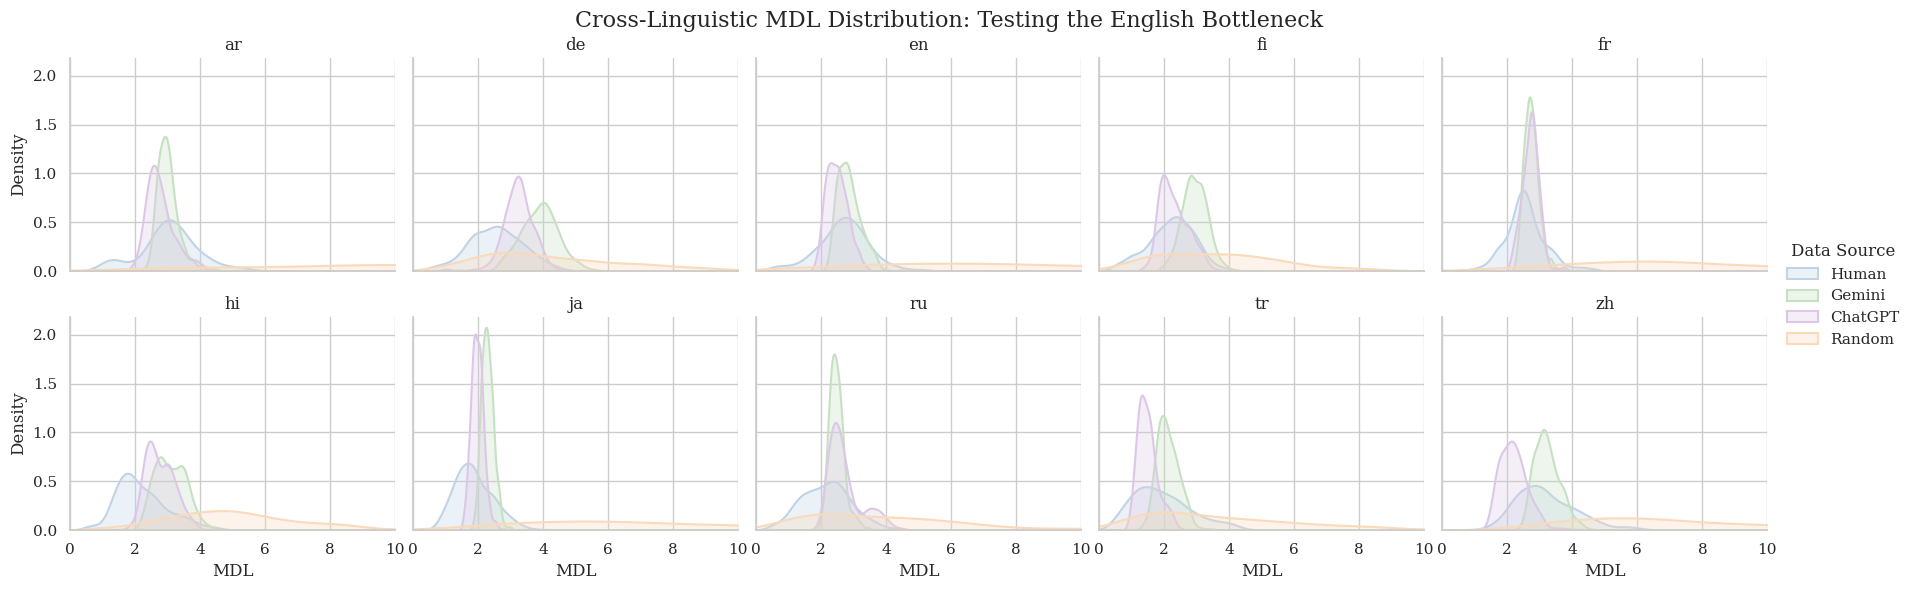

In [56]:
# 1. Create the FacetGrid
# 'col_wrap=5' creates 2 rows of 5 languages each
g = sns.FacetGrid(
    df_clean, 
    col="lang", 
    hue="source", 
    col_wrap=5, 
    palette=custom_palette, 
    hue_order=hue_order,
    height=3, 
    aspect=1.2
)

# 2. Map the KDE plot to the grid
g.map(sns.kdeplot, "dep_length", fill=True, alpha=0.3, linewidth=1.5)

# 3. Formatting
g.set_axis_labels("MDL", "Density")
g.set_titles(col_template="{col_name}") # Shows 'en', 'hi', etc.
g.add_legend(title="Data Source")
g.set(xlim=(0, 10)) # Focus on the efficiency range

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Cross-Linguistic MDL Distribution: Testing the English Bottleneck', fontsize=16)

plt.savefig('experiment3_facet_grid.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/dg/x9f6vp3x19s3clvvwpsbypy00000gn/T/ipykernel_70640/438706875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


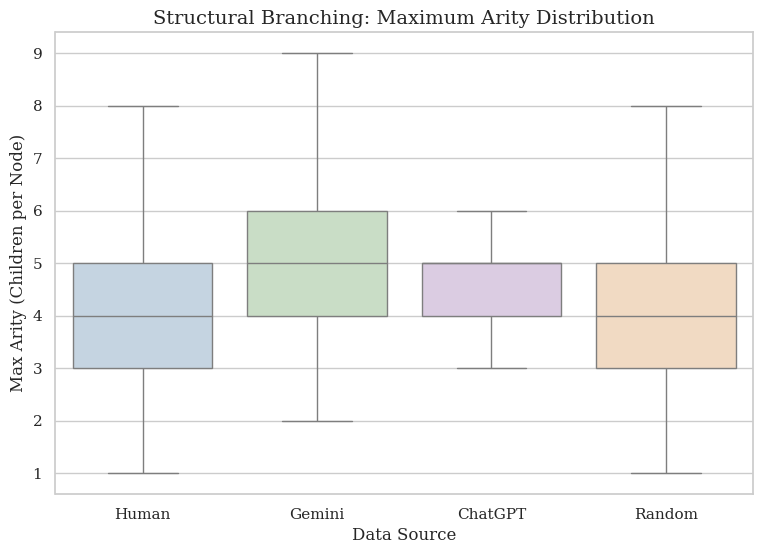

In [57]:
plt.figure(figsize=(9, 6))

# Arity is discrete, so a Boxplot or a Countplot is better than a KDE
sns.boxplot(
    data=df_clean, 
    x='source', 
    y='arity', 
    palette=custom_palette, 
    order=hue_order,
    showfliers=False # Removes outliers to make the "boxes" clear
)

plt.title("Structural Branching: Maximum Arity Distribution", fontsize=14)
plt.ylabel("Max Arity (Children per Node)")
plt.xlabel("Data Source")

plt.savefig('appendix_arity_all.png', dpi=300, bbox_inches='tight')
plt.show()